# Autoencoders en TensorFlow / Keras

Este notebook cubre el concepto de autoencoder desde sus fundamentos matematicos hasta implementaciones practicas con Keras. Se trabajan cuatro variantes: el autoencoder basico, el autoencoder convolucional, el denoising autoencoder y el variational autoencoder (VAE). El dataset utilizado es MNIST.

---

## Contenidos

1. Fundamentos matematicos
2. Preparacion del entorno y datos
3. Autoencoder basico (denso)
4. Autoencoder convolucional
5. Denoising Autoencoder
6. Variational Autoencoder (VAE)
7. Deteccion de anomalias con autoencoders
8. Comparativa de variantes

---

## 1. Fundamentos matematicos

Un autoencoder es una red neuronal que aprende dos funciones:

- **Encoder** $f_\theta$: comprime la entrada $x$ en una representacion latente $z$ de menor dimension.
$$z = f_\theta(x)$$

- **Decoder** $g_\phi$: reconstruye la entrada desde la representacion latente.
$$\hat{x} = g_\phi(z)$$

El entrenamiento minimiza el **error de reconstruccion** entre $x$ y $\hat{x}$:

$$\mathcal{L}(x, \hat{x}) = \|x - g_\phi(f_\theta(x))\|^2$$

No se usan etiquetas externas: la propia entrada es el objetivo. Esto lo convierte en un metodo de **aprendizaje no supervisado**.

### Intuicion geometrica

Si los datos viven en un espacio de dimension $D$ (imagenes de 784 pixeles), el autoencoder los proyecta en un espacio de dimension $d \ll D$ que captura la estructura esencial, y luego invierte esa proyeccion. La clave esta en el cuello de botella: al forzar la informacion a pasar por una representacion comprimida, la red no puede memorizar la entrada y debe aprender caracteristicas relevantes.

---

## 2. Preparacion del entorno y datos

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Entrenamiento : (60000, 28, 28, 1)
Prueba        : (10000, 28, 28, 1)


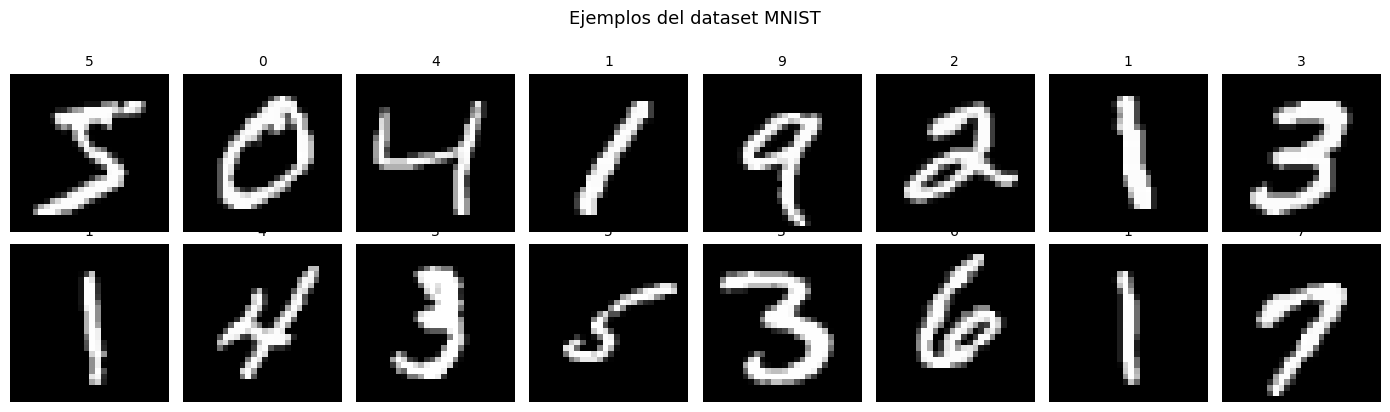

In [2]:
# Cargar MNIST y normalizar a [0, 1]
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalizar y agregar canal: (N, 28, 28) -> (N, 28, 28, 1)
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test,  -1)

print(f'Entrenamiento : {x_train.shape}')
print(f'Prueba        : {x_test.shape}')

# Visualizar ejemplos
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(16):
    ax = axes[i // 8, i % 8]
    ax.imshow(x_train[i].squeeze(), cmap='gray')
    ax.set_title(str(y_train[i]), fontsize=10)
    ax.axis('off')
plt.suptitle('Ejemplos del dataset MNIST', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## 3. Autoencoder basico (capas densas)

La variante mas simple. Encoder y decoder estan compuestos por capas densas. La imagen 28x28 se aplana a un vector de 784 antes de entrar al encoder.

**Arquitectura:**
```
Encoder: 784 -> 256 -> 128 -> 64 -> z (32)
Decoder:  32 ->  64 -> 128 -> 256 -> 784
```
El espacio latente tiene dimension 32: la imagen se comprime en un factor de ~24.5x.

In [3]:
LATENT_DIM = 32

def build_basic_autoencoder(latent_dim=32):
    """
    Construye un autoencoder denso usando la API Funcional de Keras.
    Retorna tres modelos: encoder, decoder y autoencoder completo.
    Compartir los modelos permite evaluar el espacio latente por separado.
    """
    # Encoder: comprime la imagen aplanada a un vector latente
    encoder_input  = keras.Input(shape=(28, 28, 1), name='encoder_input')
    x  = layers.Flatten()(encoder_input)
    x  = layers.Dense(256, activation='relu')(x)
    x  = layers.Dense(128, activation='relu')(x)
    x  = layers.Dense(64,  activation='relu')(x)
    z  = layers.Dense(latent_dim, name='latent')(x)
    encoder = keras.Model(encoder_input, z, name='encoder')

    # Decoder: reconstruye la imagen desde el latente
    decoder_input = keras.Input(shape=(latent_dim,), name='decoder_input')
    x = layers.Dense(64,  activation='relu')(decoder_input)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    # Sigmoid: salida en [0,1] coincide con la entrada normalizada
    x = layers.Dense(784, activation='sigmoid')(x)
    out = layers.Reshape((28, 28, 1))(x)
    decoder = keras.Model(decoder_input, out, name='decoder')

    # Autoencoder = encoder + decoder
    ae_input  = keras.Input(shape=(28, 28, 1))
    ae_output = decoder(encoder(ae_input))
    autoencoder = keras.Model(ae_input, ae_output, name='autoencoder')

    return encoder, decoder, autoencoder


ae_encoder, ae_decoder, ae = build_basic_autoencoder(LATENT_DIM)
ae.compile(optimizer='adam', loss='mse')

print(f'Parametros entrenables: {ae.count_params():,}')
ae.summary()

Parametros entrenables: 489,136


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 32)             │       244,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 28, 28, 1)      │       244,944 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 489,136 (1.87 MB)

 Trainable params: 489,136 (1.87 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# El autoencoder se entrena con keras estandar: x como entrada y x como objetivo
print('Entrenando el autoencoder basico...')
history_ae = ae.fit(
    x_train, x_train,            # x es entrada Y objetivo
    validation_data=(x_test, x_test),
    epochs=20,
    batch_size=128,
    verbose=2,
)

Entrenando el autoencoder basico...
Epoch 1/20
469/469 - 9s - 20ms/step - loss: 0.0456 - val_loss: 0.0247
Epoch 2/20
469/469 - 1s - 3ms/step - loss: 0.0211 - val_loss: 0.0178
Epoch 3/20
469/469 - 2s - 3ms/step - loss: 0.0167 - val_loss: 0.0152
Epoch 4/20
469/469 - 2s - 3ms/step - loss: 0.0142 - val_loss: 0.0132
Epoch 5/20
469/469 - 2s - 3ms/step - loss: 0.0128 - val_loss: 0.0122
Epoch 6/20
469/469 - 2s - 4ms/step - loss: 0.0118 - val_loss: 0.0113
Epoch 7/20
469/469 - 2s - 4ms/step - loss: 0.0109 - val_loss: 0.0105
Epoch 8/20
469/469 - 2s - 3ms/step - loss: 0.0102 - val_loss: 0.0098
Epoch 9/20
469/469 - 2s - 4ms/step - loss: 0.0097 - val_loss: 0.0094
Epoch 10/20
469/469 - 2s - 4ms/step - loss: 0.0093 - val_loss: 0.0090
Epoch 11/20
469/469 - 2s - 3ms/step - loss: 0.0090 - val_loss: 0.0088
Epoch 12/20
469/469 - 2s - 3ms/step - loss: 0.0087 - val_loss: 0.0085
Epoch 13/20
469/469 - 2s - 4ms/step - loss: 0.0084 - val_loss: 0.0082
Epoch 14/20
469/469 - 2s - 4ms/step - loss: 0.0082 - val_loss:

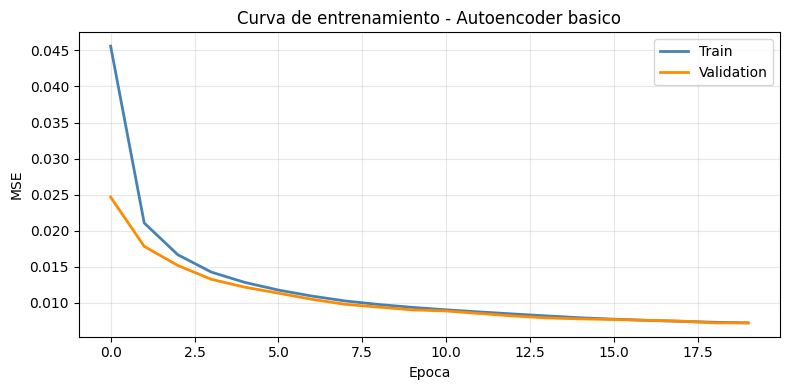

In [5]:
# Curva de perdida
plt.figure(figsize=(8, 4))
plt.plot(history_ae.history['loss'],     label='Train',      color='steelblue', linewidth=2)
plt.plot(history_ae.history['val_loss'], label='Validation', color='darkorange', linewidth=2)
plt.xlabel('Epoca'); plt.ylabel('MSE')
plt.title('Curva de entrenamiento - Autoencoder basico')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

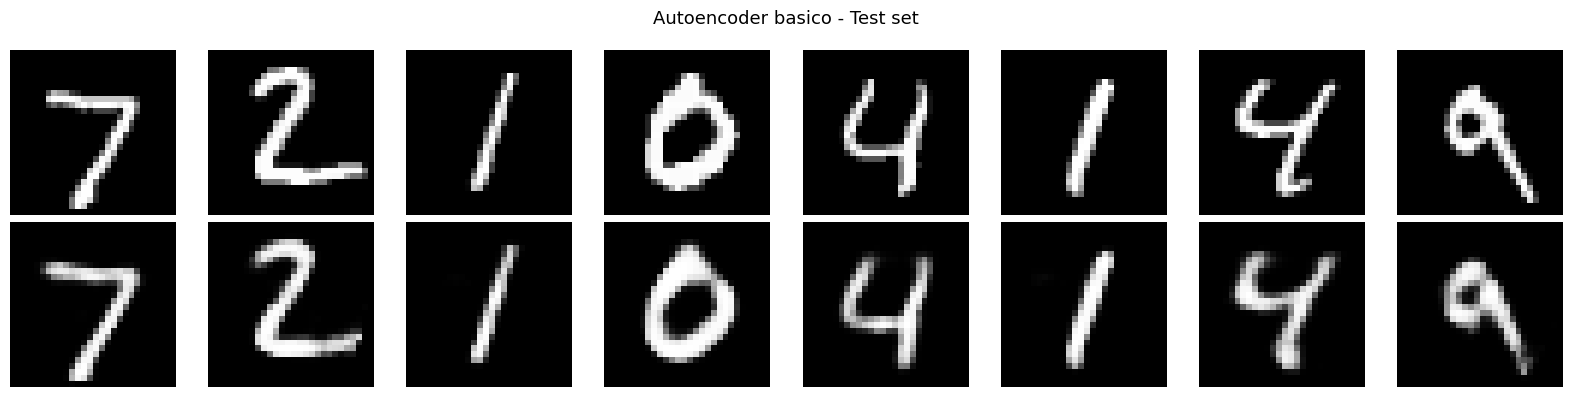

In [6]:
def visualize_reconstructions(autoencoder, x, n=8, title='Reconstrucciones'):
    """Muestra imagenes originales y sus reconstrucciones."""
    recon = autoencoder.predict(x[:n], verbose=0)

    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i in range(n):
        axes[0, i].imshow(x[i].squeeze(),     cmap='gray'); axes[0, i].axis('off')
        axes[1, i].imshow(recon[i].squeeze(), cmap='gray'); axes[1, i].axis('off')
    axes[0, 0].set_ylabel('Original',     fontsize=10, rotation=0, labelpad=40, va='center')
    axes[1, 0].set_ylabel('Reconstruida', fontsize=10, rotation=0, labelpad=40, va='center')
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


visualize_reconstructions(ae, x_test, title='Autoencoder basico - Test set')

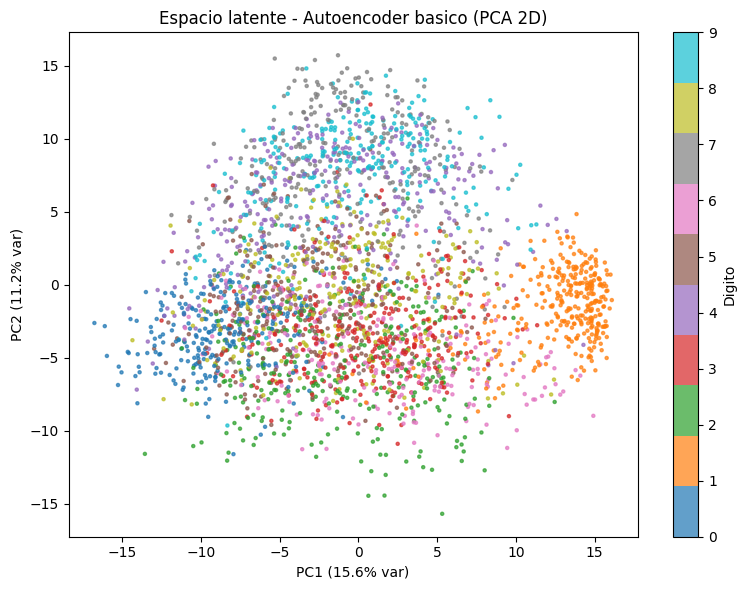

In [7]:
def visualize_latent_space(encoder, x, y, n_samples=3000, title='Espacio latente'):
    """
    Proyecta el espacio latente en 2D usando PCA y colorea por digito.
    Permite ver si el modelo agrupa los digitos en el espacio latente,
    aunque no fue entrenado con etiquetas.
    """
    z   = encoder.predict(x[:n_samples], verbose=0)
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z)

    plt.figure(figsize=(8, 6))
    sc = plt.scatter(z_2d[:, 0], z_2d[:, 1], c=y[:n_samples],
                     cmap='tab10', s=5, alpha=0.7)
    plt.colorbar(sc, label='Digito')
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
    plt.title(title)
    plt.tight_layout()
    plt.show()


visualize_latent_space(ae_encoder, x_test, y_test,
                       title='Espacio latente - Autoencoder basico (PCA 2D)')

### Observacion

A pesar de que el modelo no fue entrenado con etiquetas, el espacio latente muestra una organizacion que refleja la estructura real de los datos: digitos similares tienden a agruparse en regiones proximas. Esto demuestra que el autoencoder aprende caracteristicas semanticamente significativas de forma no supervisada.

---

## 4. Autoencoder Convolucional

Las capas densas tratan cada pixel de forma independiente. Las **capas convolucionales** comparten pesos y explotan la correlacion local entre pixeles vecinos, lo que las hace mas adecuadas para imagenes.

**Arquitectura:**
```
Encoder:
  (28, 28, 1) -> Conv2D(32) + MaxPool -> (14, 14, 32)
  -> Conv2D(64) + MaxPool -> (7, 7, 64)
  -> Flatten + Dense -> latent (32)

Decoder:
  latent -> Dense + Reshape -> (7, 7, 64)
  -> Conv2DTranspose -> (14, 14, 64)
  -> Conv2DTranspose -> (28, 28, 32)
  -> Conv2D(1, sigmoid) -> (28, 28, 1)
```

In [8]:
def build_conv_autoencoder(latent_dim=32):
    """Autoencoder convolucional con Conv2D y Conv2DTranspose."""
    # Encoder
    enc_in = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(enc_in)
    x = layers.MaxPooling2D(2)(x)                       # (14, 14, 32)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D(2)(x)                       # (7, 7, 64)
    x = layers.Flatten()(x)                             # (3136,)
    z = layers.Dense(latent_dim, name='latent')(x)
    encoder = keras.Model(enc_in, z, name='conv_encoder')

    # Decoder
    dec_in = keras.Input(shape=(latent_dim,))
    x = layers.Dense(64 * 7 * 7, activation='relu')(dec_in)
    x = layers.Reshape((7, 7, 64))(x)
    # Conv2DTranspose con stride=2 duplica la resolucion espacial
    x = layers.Conv2DTranspose(64, 3, strides=2, activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)
    out = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)
    decoder = keras.Model(dec_in, out, name='conv_decoder')

    # Autoencoder
    ae_in  = keras.Input(shape=(28, 28, 1))
    ae_out = decoder(encoder(ae_in))
    autoencoder = keras.Model(ae_in, ae_out, name='conv_autoencoder')

    return encoder, decoder, autoencoder


conv_encoder, conv_decoder, conv_ae = build_conv_autoencoder(LATENT_DIM)
conv_ae.compile(optimizer='adam', loss='mse')

print(f'Parametros (Conv AE): {conv_ae.count_params():,}')

Parametros (Conv AE): 278,369


Entrenando autoencoder convolucional...
Epoch 1/20
469/469 - 13s - 28ms/step - loss: 0.0383 - val_loss: 0.0099
Epoch 2/20
469/469 - 4s - 8ms/step - loss: 0.0079 - val_loss: 0.0063
Epoch 3/20
469/469 - 4s - 9ms/step - loss: 0.0058 - val_loss: 0.0053
Epoch 4/20
469/469 - 4s - 8ms/step - loss: 0.0050 - val_loss: 0.0047
Epoch 5/20
469/469 - 4s - 8ms/step - loss: 0.0046 - val_loss: 0.0044
Epoch 6/20
469/469 - 4s - 9ms/step - loss: 0.0043 - val_loss: 0.0042
Epoch 7/20
469/469 - 4s - 8ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 8/20
469/469 - 4s - 8ms/step - loss: 0.0039 - val_loss: 0.0039
Epoch 9/20
469/469 - 5s - 10ms/step - loss: 0.0037 - val_loss: 0.0038
Epoch 10/20
469/469 - 4s - 9ms/step - loss: 0.0036 - val_loss: 0.0037
Epoch 11/20
469/469 - 4s - 8ms/step - loss: 0.0035 - val_loss: 0.0036
Epoch 12/20
469/469 - 4s - 9ms/step - loss: 0.0035 - val_loss: 0.0035
Epoch 13/20
469/469 - 4s - 8ms/step - loss: 0.0034 - val_loss: 0.0035
Epoch 14/20
469/469 - 4s - 8ms/step - loss: 0.0033 - val

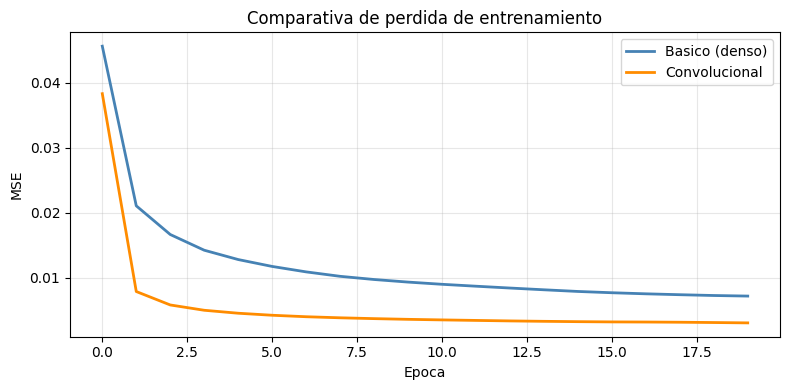

In [9]:
print('Entrenando autoencoder convolucional...')
history_conv = conv_ae.fit(
    x_train, x_train,
    validation_data=(x_test, x_test),
    epochs=20, batch_size=128, verbose=2,
)

# Comparativa de curvas
plt.figure(figsize=(8, 4))
plt.plot(history_ae.history['loss'],   label='Basico (denso)',   color='steelblue', linewidth=2)
plt.plot(history_conv.history['loss'], label='Convolucional',     color='darkorange', linewidth=2)
plt.xlabel('Epoca'); plt.ylabel('MSE')
plt.title('Comparativa de perdida de entrenamiento')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

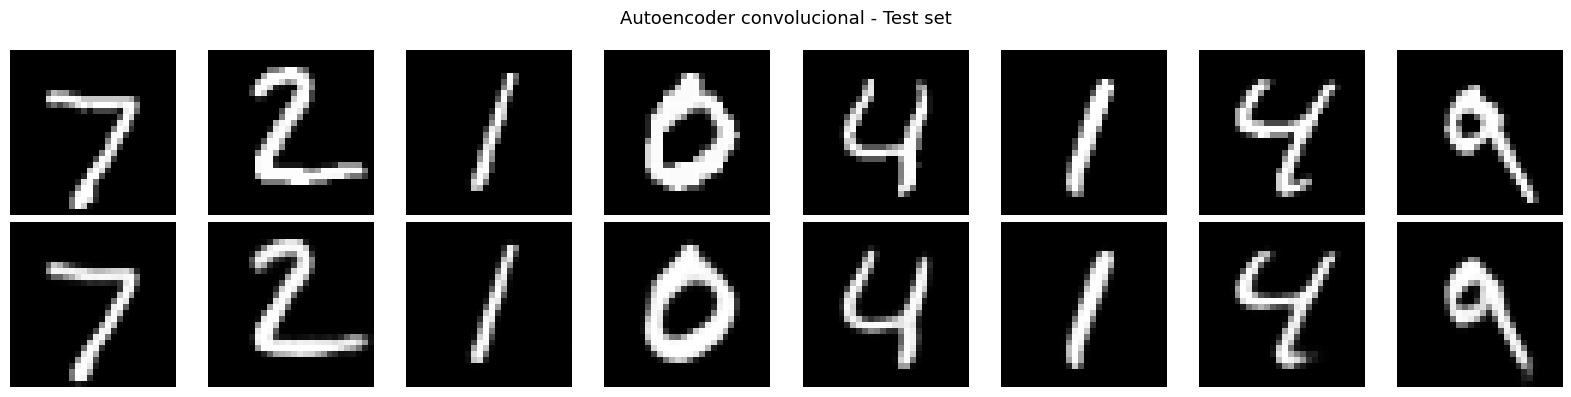

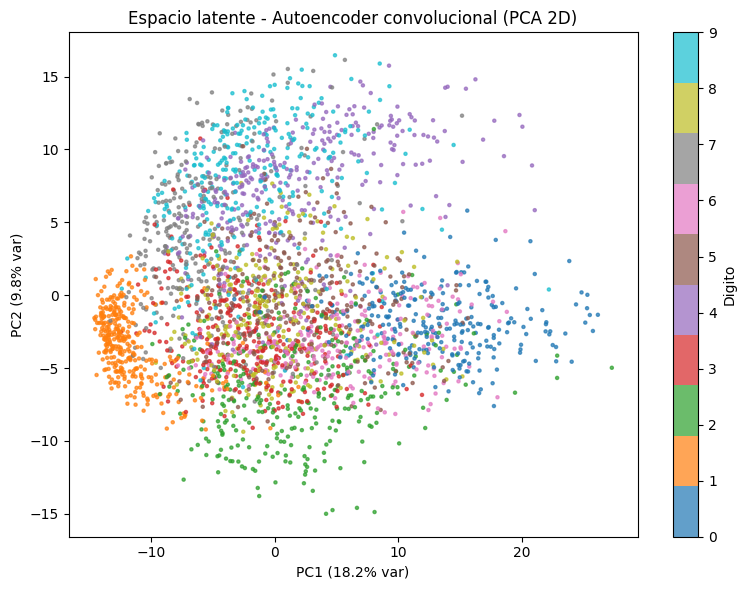

In [10]:
visualize_reconstructions(conv_ae, x_test, title='Autoencoder convolucional - Test set')
visualize_latent_space(conv_encoder, x_test, y_test,
                       title='Espacio latente - Autoencoder convolucional (PCA 2D)')

---

## 5. Denoising Autoencoder (DAE)

El **denoising autoencoder** entrena el modelo para que aprenda a eliminar el ruido. En lugar de pasarle la imagen limpia, se le pasa una version corrompida y la red debe reconstruir la original sin ruido:

$$\hat{x} = g_\phi(f_\theta(\tilde{x})), \quad \tilde{x} = x + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2)$$

Esto fuerza a aprender representaciones **robustas**: no puede memorizar detalles superficiales del ruido, debe capturar la estructura global del digito.

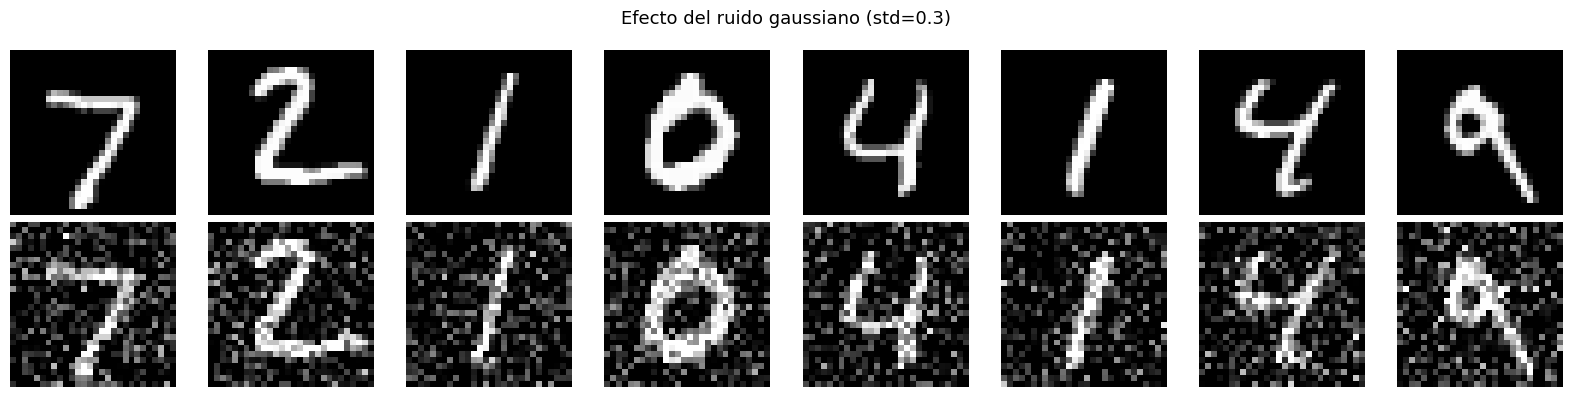

In [11]:
def add_gaussian_noise(images, std=0.3):
    """Agrega ruido gaussiano y recorta a [0, 1]."""
    noise  = np.random.normal(0, std, images.shape).astype('float32')
    return np.clip(images + noise, 0.0, 1.0)


# Crear versiones con ruido para entrenamiento
NOISE_STD     = 0.3
x_train_noisy = add_gaussian_noise(x_train, NOISE_STD)
x_test_noisy  = add_gaussian_noise(x_test,  NOISE_STD)

# Visualizar el efecto del ruido
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(x_test[i].squeeze(),       cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original',  fontsize=10, rotation=0, labelpad=40, va='center')
axes[1, 0].set_ylabel('Con ruido', fontsize=10, rotation=0, labelpad=40, va='center')
plt.suptitle(f'Efecto del ruido gaussiano (std={NOISE_STD})', fontsize=13)
plt.tight_layout()
plt.show()

In [12]:
# Entrenar el DAE: misma arquitectura conv, pero entrenamiento distinto
# Entrada: imagen ruidosa  |  Objetivo: imagen limpia
_, _, dae = build_conv_autoencoder(LATENT_DIM)
dae.compile(optimizer='adam', loss='mse')

print('Entrenando Denoising Autoencoder...')
history_dae = dae.fit(
    x_train_noisy, x_train,                              # noisy in, clean out
    validation_data=(x_test_noisy, x_test),
    epochs=20, batch_size=128, verbose=2,
)

Entrenando Denoising Autoencoder...
Epoch 1/20
469/469 - 11s - 23ms/step - loss: 0.0500 - val_loss: 0.0164
Epoch 2/20
469/469 - 4s - 9ms/step - loss: 0.0126 - val_loss: 0.0100
Epoch 3/20
469/469 - 4s - 9ms/step - loss: 0.0092 - val_loss: 0.0085
Epoch 4/20
469/469 - 4s - 9ms/step - loss: 0.0081 - val_loss: 0.0078
Epoch 5/20
469/469 - 4s - 9ms/step - loss: 0.0075 - val_loss: 0.0074
Epoch 6/20
469/469 - 4s - 9ms/step - loss: 0.0072 - val_loss: 0.0071
Epoch 7/20
469/469 - 4s - 9ms/step - loss: 0.0069 - val_loss: 0.0070
Epoch 8/20
469/469 - 4s - 9ms/step - loss: 0.0067 - val_loss: 0.0068
Epoch 9/20
469/469 - 4s - 9ms/step - loss: 0.0065 - val_loss: 0.0067
Epoch 10/20
469/469 - 4s - 9ms/step - loss: 0.0064 - val_loss: 0.0066
Epoch 11/20
469/469 - 4s - 9ms/step - loss: 0.0062 - val_loss: 0.0065
Epoch 12/20
469/469 - 4s - 9ms/step - loss: 0.0061 - val_loss: 0.0065
Epoch 13/20
469/469 - 4s - 9ms/step - loss: 0.0060 - val_loss: 0.0064
Epoch 14/20
469/469 - 4s - 9ms/step - loss: 0.0059 - val_loss

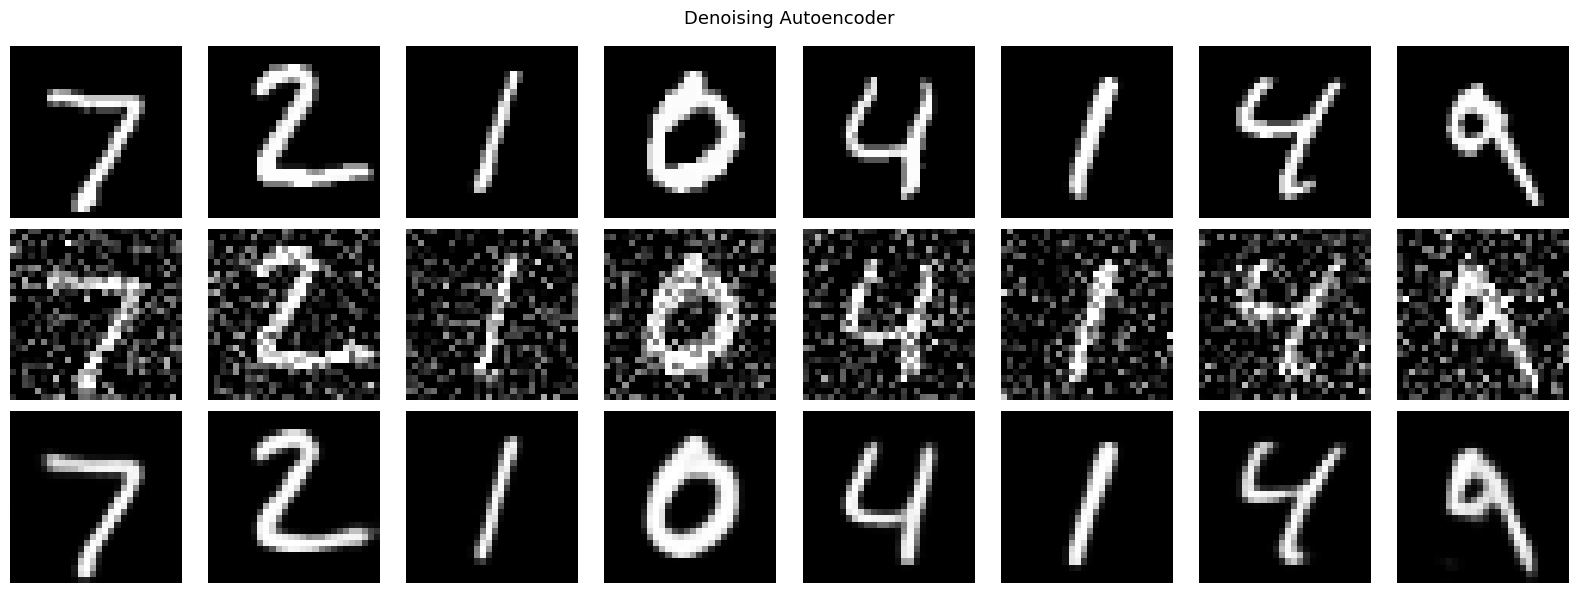

In [13]:
# Visualizar denoising en tres filas: original / ruidosa / reconstruida
n = 8
recon = dae.predict(x_test_noisy[:n], verbose=0)

fig, axes = plt.subplots(3, n, figsize=(2*n, 6))
etiquetas = ['Original', f'Ruidosa (std={NOISE_STD})', 'Reconstruida']
datos     = [x_test[:n], x_test_noisy[:n], recon]

for row, (data, label) in enumerate(zip(datos, etiquetas)):
    for col in range(n):
        axes[row, col].imshow(data[col].squeeze(), cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(label, fontsize=10, rotation=0, labelpad=55, va='center')

plt.suptitle('Denoising Autoencoder', fontsize=13)
plt.tight_layout()
plt.show()

---

## 6. Variational Autoencoder (VAE)

El **VAE** (Kingma & Welling, 2013) convierte el bottleneck en una **distribucion de probabilidad** sobre el espacio latente:

$$z \sim q_\phi(z|x) = \mathcal{N}(\mu_\phi(x), \sigma^2_\phi(x))$$

### Funcion de perdida (ELBO)

$$\mathcal{L}_{\text{VAE}} = \underbrace{\mathbb{E}[\log p_\theta(x|z)]}_{\text{reconstruccion}} - \underbrace{D_{KL}(q_\phi(z|x) \| p(z))}_{\text{regularizacion}}$$

- **Reconstruccion**: BCE pixel a pixel.
- **KL**: fuerza al posterior a parecerse a la prior $\mathcal{N}(0, I)$, regularizando el espacio latente.

### Truco de reparametrizacion

El muestreo $z \sim \mathcal{N}(\mu, \sigma^2)$ no es diferenciable. Se descompone:

$$z = \mu + \sigma \cdot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

El gradiente fluye a traves de $\mu$ y $\sigma$ mientras $\epsilon$ es ruido externo.

In [14]:
VAE_LATENT_DIM = 16

class Sampling(layers.Layer):
    """
    Capa que implementa el truco de reparametrizacion.
    z = mu + exp(0.5 * log_var) * epsilon, con epsilon ~ N(0, I).
    """
    def call(self, inputs):
        mu, log_var = inputs
        batch       = tf.shape(mu)[0]
        dim         = tf.shape(mu)[1]
        epsilon     = tf.random.normal(shape=(batch, dim))
        return mu + tf.exp(0.5 * log_var) * epsilon


def build_vae_encoder(latent_dim=16):
    """Encoder del VAE: produce mu y log_var en lugar de un z fijo."""
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Flatten()(inputs)
    x = layers.Dense(400, activation='relu')(x)
    x = layers.Dense(200, activation='relu')(x)
    mu      = layers.Dense(latent_dim, name='mu')(x)
    log_var = layers.Dense(latent_dim, name='log_var')(x)
    z = Sampling(name='z')([mu, log_var])
    return keras.Model(inputs, [mu, log_var, z], name='vae_encoder')


def build_vae_decoder(latent_dim=16):
    inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(200, activation='relu')(inputs)
    x = layers.Dense(400, activation='relu')(x)
    x = layers.Dense(784, activation='sigmoid')(x)
    out = layers.Reshape((28, 28, 1))(x)
    return keras.Model(inputs, out, name='vae_decoder')


class VAE(keras.Model):
    """
    VAE como subclase de keras.Model.
    Implementa train_step personalizado para combinar perdida de reconstruccion + KL.
    """
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta    = beta
        # Trackers para mostrar las dos componentes de la perdida en el log
        self.total_loss_tracker = keras.metrics.Mean(name='loss')
        self.recon_loss_tracker = keras.metrics.Mean(name='recon_loss')
        self.kl_loss_tracker    = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        _, _, z = self.encoder(inputs)
        return self.decoder(z)

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            mu, log_var, z = self.encoder(data)
            recon          = self.decoder(z)

            # Perdida de reconstruccion: BCE sobre todos los pixeles del batch
            recon_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, recon),
                    axis=(1, 2)
                )
            )

            # KL divergence en forma cerrada para gaussianas
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + log_var - tf.square(mu) - tf.exp(log_var), axis=1)
            )

            total_loss = recon_loss + self.beta * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {m.name: m.result() for m in self.metrics}


# Construir y compilar VAE
vae_encoder = build_vae_encoder(VAE_LATENT_DIM)
vae_decoder = build_vae_decoder(VAE_LATENT_DIM)
vae         = VAE(vae_encoder, vae_decoder, beta=1.0)
vae.compile(optimizer=keras.optimizers.Adam(1e-3))

print(f'Parametros encoder: {vae_encoder.count_params():,}')
print(f'Parametros decoder: {vae_decoder.count_params():,}')

Parametros encoder: 400,632
Parametros decoder: 398,184


In [15]:
print('Entrenando VAE...')
history_vae = vae.fit(x_train, epochs=30, batch_size=128, verbose=2)

Entrenando VAE...
Epoch 1/30
469/469 - 7s - 15ms/step - kl_loss: 11.3020 - loss: 167.3349 - recon_loss: 156.0329
Epoch 2/30
469/469 - 2s - 3ms/step - kl_loss: 18.5147 - loss: 122.8754 - recon_loss: 104.3608
Epoch 3/30
469/469 - 2s - 4ms/step - kl_loss: 20.2008 - loss: 114.7540 - recon_loss: 94.5532
Epoch 4/30
469/469 - 2s - 3ms/step - kl_loss: 20.8590 - loss: 111.1494 - recon_loss: 90.2904
Epoch 5/30
469/469 - 2s - 3ms/step - kl_loss: 21.2330 - loss: 109.0725 - recon_loss: 87.8395
Epoch 6/30
469/469 - 2s - 3ms/step - kl_loss: 21.4399 - loss: 107.6502 - recon_loss: 86.2103
Epoch 7/30
469/469 - 2s - 3ms/step - kl_loss: 21.5980 - loss: 106.5726 - recon_loss: 84.9745
Epoch 8/30
469/469 - 2s - 3ms/step - kl_loss: 21.7087 - loss: 105.6478 - recon_loss: 83.9391
Epoch 9/30
469/469 - 2s - 3ms/step - kl_loss: 21.8464 - loss: 104.9577 - recon_loss: 83.1114
Epoch 10/30
469/469 - 2s - 4ms/step - kl_loss: 21.9010 - loss: 104.3115 - recon_loss: 82.4105
Epoch 11/30
469/469 - 2s - 4ms/step - kl_loss: 2

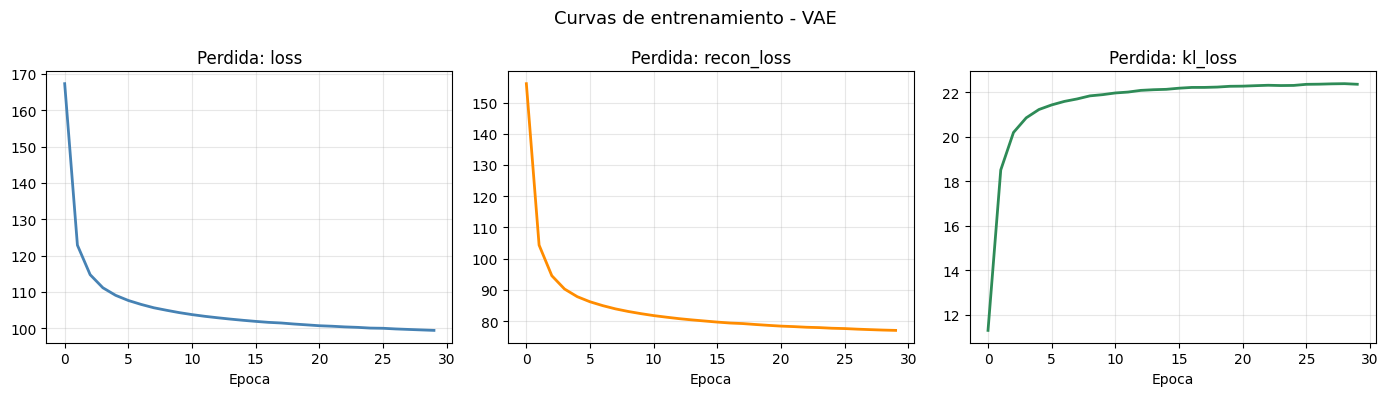

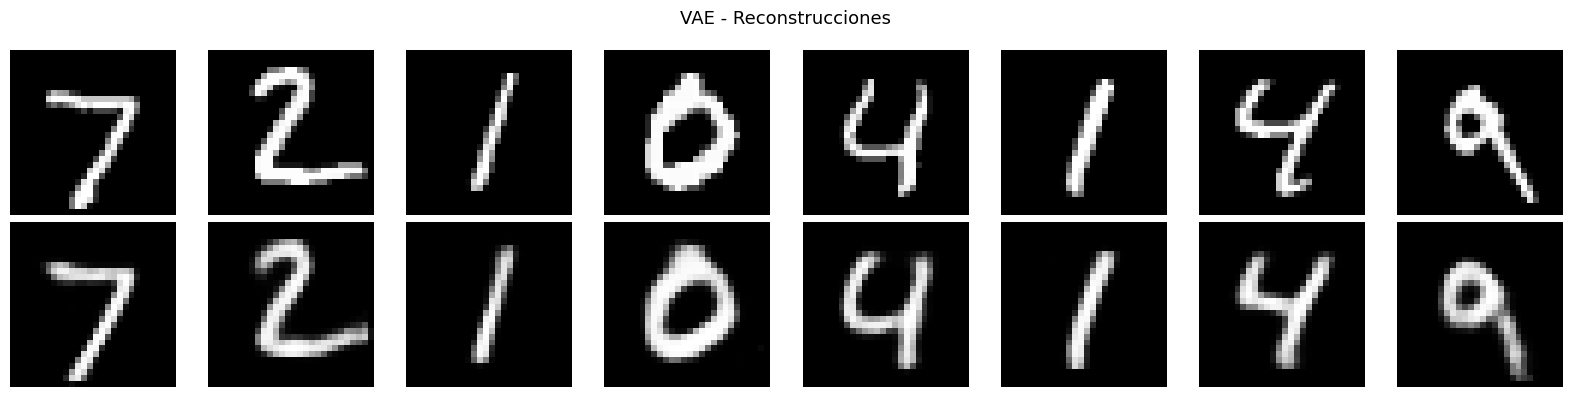

In [16]:
# Curvas de las tres componentes de la perdida
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, key, color in zip(axes, ['loss', 'recon_loss', 'kl_loss'],
                          ['steelblue', 'darkorange', 'seagreen']):
    ax.plot(history_vae.history[key], color=color, linewidth=2)
    ax.set_title(f'Perdida: {key}', fontsize=12)
    ax.set_xlabel('Epoca')
    ax.grid(True, alpha=0.3)
plt.suptitle('Curvas de entrenamiento - VAE', fontsize=13)
plt.tight_layout()
plt.show()

# Reconstrucciones del VAE
n = 8
recon_vae = vae.predict(x_test[:n], verbose=0)
fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
for i in range(n):
    axes[0, i].imshow(x_test[i].squeeze(),     cmap='gray'); axes[0, i].axis('off')
    axes[1, i].imshow(recon_vae[i].squeeze(),  cmap='gray'); axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original',     fontsize=10, rotation=0, labelpad=40, va='center')
axes[1, 0].set_ylabel('Reconstruida', fontsize=10, rotation=0, labelpad=40, va='center')
plt.suptitle('VAE - Reconstrucciones', fontsize=13)
plt.tight_layout()
plt.show()

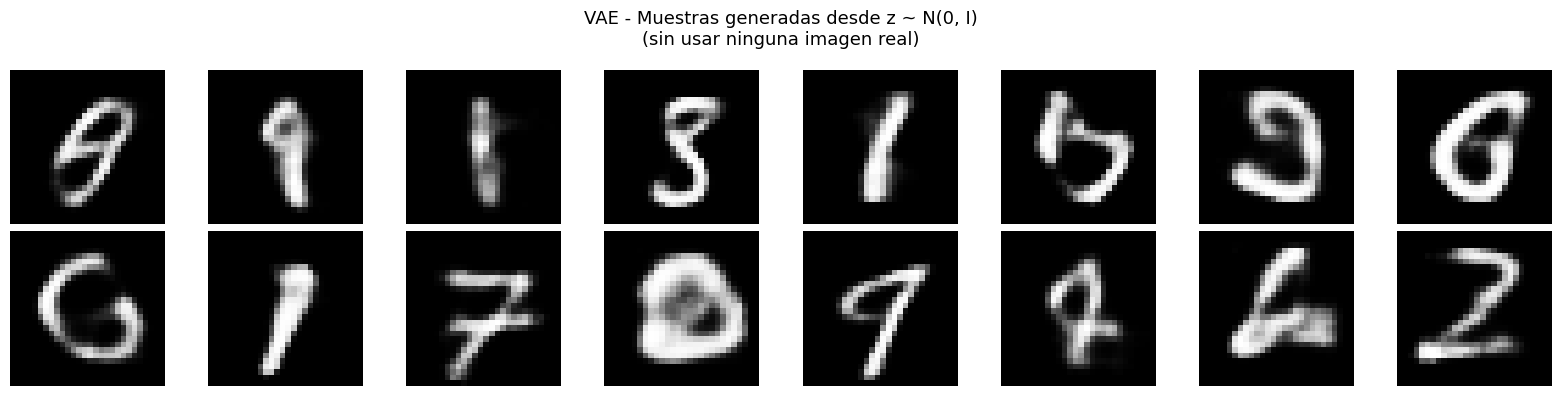

In [17]:
# Generacion de muestras nuevas: muestrear z desde la prior N(0, I)
# Esta es la capacidad GENERATIVA exclusiva del VAE
z_sample  = np.random.normal(0, 1, size=(16, VAE_LATENT_DIM)).astype('float32')
generated = vae_decoder.predict(z_sample, verbose=0)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(16):
    axes[i // 8, i % 8].imshow(generated[i].squeeze(), cmap='gray')
    axes[i // 8, i % 8].axis('off')
plt.suptitle('VAE - Muestras generadas desde z ~ N(0, I)\n(sin usar ninguna imagen real)', fontsize=13)
plt.tight_layout()
plt.show()

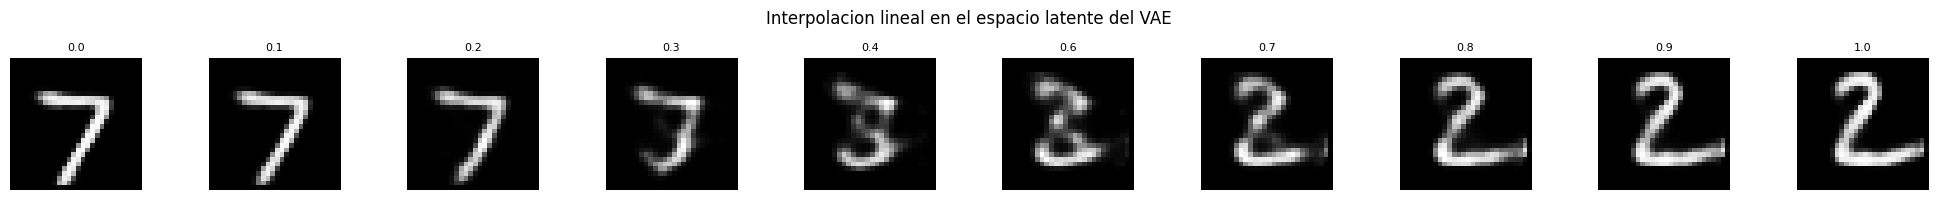

In [18]:
def interpolate_latent(encoder, decoder, x, steps=10, latent_dim=16):
    """
    Interpolacion lineal entre dos puntos del espacio latente.
    Gracias a la regularizacion KL del VAE, los puntos intermedios producen
    imagenes coherentes y la transicion es suave.
    """
    mu, _, _ = encoder.predict(x[:2], verbose=0)
    z1, z2   = mu[0], mu[1]
    alphas   = np.linspace(0, 1, steps).astype('float32').reshape(-1, 1)
    z_interp = (1 - alphas) * z1 + alphas * z2
    recon    = decoder.predict(z_interp, verbose=0)

    fig, axes = plt.subplots(1, steps, figsize=(2*steps, 2))
    for i, ax in enumerate(axes):
        ax.imshow(recon[i].squeeze(), cmap='gray')
        ax.axis('off')
        ax.set_title(f'{alphas[i, 0]:.1f}', fontsize=8)
    plt.suptitle('Interpolacion lineal en el espacio latente del VAE', fontsize=12)
    plt.tight_layout()
    plt.show()


interpolate_latent(vae_encoder, vae_decoder, x_test, steps=10, latent_dim=VAE_LATENT_DIM)

---

## 7. Deteccion de anomalias con autoencoders

1. Entrenar el autoencoder **solo con datos normales** (digito 0).
2. El modelo aprende a reconstruir bien lo normal.
3. Una **anomalia** (cualquier otro digito) tendra error de reconstruccion alto.

$$\text{score}(x) = \|x - \hat{x}\|^2 \quad \begin{cases} \text{bajo} & \Rightarrow \text{normal} \\ \text{alto} & \Rightarrow \text{anomalia} \end{cases}$$

In [19]:
NORMAL_CLASS = 0

# Filtrar solo la clase normal del set de entrenamiento
x_train_normal = x_train[y_train == NORMAL_CLASS]
print(f'Ejemplos normales (digito {NORMAL_CLASS}) : {len(x_train_normal):,}')
print(f'Total entrenamiento original             : {len(x_train):,}')

# Entrenar autoencoder solo con la clase normal
_, _, anomaly_ae = build_basic_autoencoder(latent_dim=16)
anomaly_ae.compile(optimizer='adam', loss='mse')

print(f'\nEntrenando solo con digito {NORMAL_CLASS}...')
anomaly_ae.fit(x_train_normal, x_train_normal,
               epochs=20, batch_size=128, verbose=2)

Ejemplos normales (digito 0) : 5,923
Total entrenamiento original             : 60,000

Entrenando solo con digito 0...
Epoch 1/20
47/47 - 5s - 108ms/step - loss: 0.0940
Epoch 2/20
47/47 - 0s - 4ms/step - loss: 0.0538
Epoch 3/20
47/47 - 0s - 4ms/step - loss: 0.0396
Epoch 4/20
47/47 - 0s - 4ms/step - loss: 0.0355
Epoch 5/20
47/47 - 0s - 4ms/step - loss: 0.0306
Epoch 6/20
47/47 - 0s - 4ms/step - loss: 0.0274
Epoch 7/20
47/47 - 0s - 4ms/step - loss: 0.0249
Epoch 8/20
47/47 - 0s - 4ms/step - loss: 0.0222
Epoch 9/20
47/47 - 0s - 4ms/step - loss: 0.0195
Epoch 10/20
47/47 - 0s - 4ms/step - loss: 0.0180
Epoch 11/20
47/47 - 0s - 4ms/step - loss: 0.0170
Epoch 12/20
47/47 - 0s - 4ms/step - loss: 0.0162
Epoch 13/20
47/47 - 0s - 4ms/step - loss: 0.0155
Epoch 14/20
47/47 - 0s - 4ms/step - loss: 0.0149
Epoch 15/20
47/47 - 0s - 4ms/step - loss: 0.0145
Epoch 16/20
47/47 - 0s - 4ms/step - loss: 0.0142
Epoch 17/20
47/47 - 0s - 4ms/step - loss: 0.0140
Epoch 18/20
47/47 - 0s - 4ms/step - loss: 0.0137
Epoch

In [20]:
# Calcular error de reconstruccion en todo el test set
recon_test = anomaly_ae.predict(x_test, verbose=0)
errors     = np.mean((x_test - recon_test) ** 2, axis=(1, 2, 3))

normal_errors  = errors[y_test == NORMAL_CLASS]
anomaly_errors = errors[y_test != NORMAL_CLASS]

print(f'Error promedio - Normal ({NORMAL_CLASS})  : {normal_errors.mean():.5f}')
print(f'Error promedio - Anomalia               : {anomaly_errors.mean():.5f}')
print(f'Razon anomalia/normal                   : {anomaly_errors.mean()/normal_errors.mean():.1f}x')

Error promedio - Normal (0)  : 0.01380
Error promedio - Anomalia               : 0.05494
Razon anomalia/normal                   : 4.0x


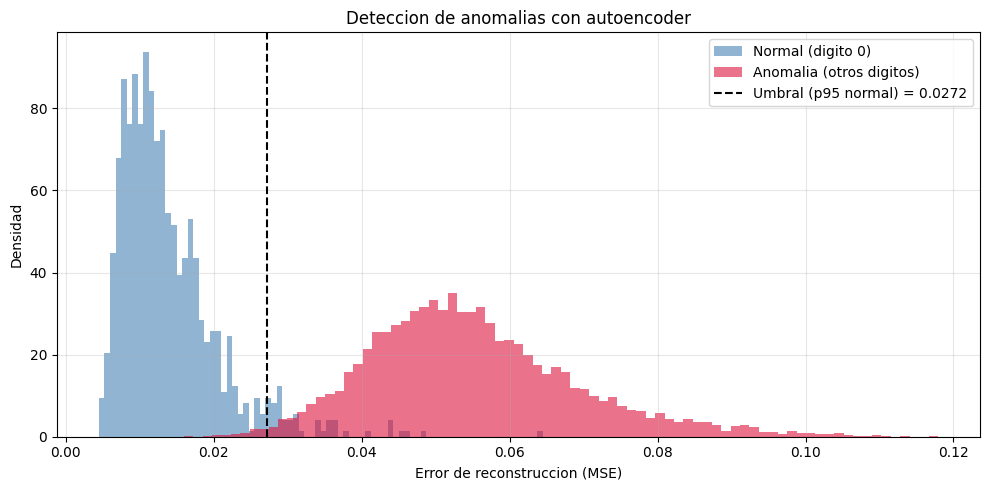

Resultados con umbral = 0.0272
  Precision : 0.995
  Recall    : 0.992
  Accuracy  : 0.988


In [21]:
# Histograma de errores con umbral
plt.figure(figsize=(10, 5))
plt.hist(normal_errors,  bins=80, alpha=0.6, label=f'Normal (digito {NORMAL_CLASS})',
         color='steelblue', density=True)
plt.hist(anomaly_errors, bins=80, alpha=0.6, label='Anomalia (otros digitos)',
         color='crimson', density=True)

threshold = np.percentile(normal_errors, 95)
plt.axvline(threshold, color='black', linestyle='--', linewidth=1.5,
            label=f'Umbral (p95 normal) = {threshold:.4f}')
plt.xlabel('Error de reconstruccion (MSE)')
plt.ylabel('Densidad')
plt.title('Deteccion de anomalias con autoencoder')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Metricas con ese umbral
labels_bin  = (y_test != NORMAL_CLASS).astype(int)
predictions = (errors > threshold).astype(int)

tp = np.sum((predictions == 1) & (labels_bin == 1))
fp = np.sum((predictions == 1) & (labels_bin == 0))
fn = np.sum((predictions == 0) & (labels_bin == 1))
tn = np.sum((predictions == 0) & (labels_bin == 0))

print(f'Resultados con umbral = {threshold:.4f}')
print(f'  Precision : {tp/(tp+fp+1e-8):.3f}')
print(f'  Recall    : {tp/(tp+fn+1e-8):.3f}')
print(f'  Accuracy  : {(tp+tn)/len(y_test):.3f}')

---

## 8. Comparativa de variantes

MSE de reconstruccion en test
---------------------------------------------
AE Basico (denso)            0.007200
AE Convolucional             0.003308
Denoising AE (noisy in)      0.006154
VAE                          0.012225


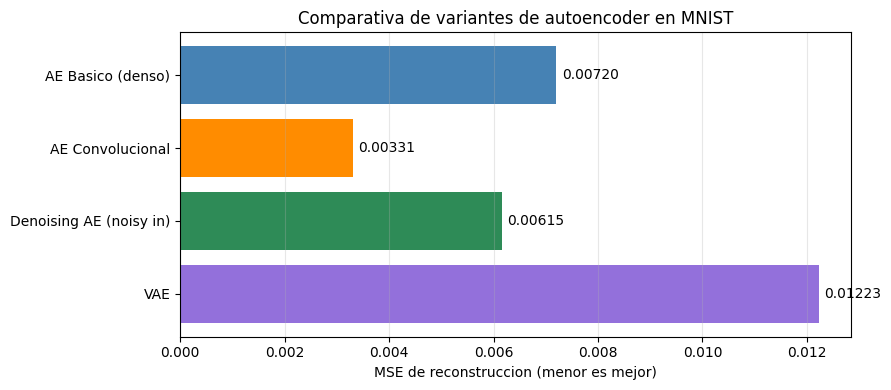

In [22]:
def evaluate_mse(model, x, x_target=None):
    """Calcula el MSE de reconstruccion."""
    if x_target is None: x_target = x
    recon = model.predict(x, verbose=0)
    return np.mean((x_target - recon) ** 2)


results = {
    'AE Basico (denso)'      : evaluate_mse(ae,      x_test),
    'AE Convolucional'       : evaluate_mse(conv_ae, x_test),
    'Denoising AE (noisy in)': evaluate_mse(dae,     x_test_noisy, x_test),
    'VAE'                    : evaluate_mse(vae,     x_test),
}

print('MSE de reconstruccion en test')
print('-' * 45)
for name, mse in results.items():
    print(f'{name:<28} {mse:.6f}')

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(list(results.keys()), list(results.values()),
               color=['steelblue', 'darkorange', 'seagreen', 'mediumpurple'])
ax.bar_label(bars, fmt='%.5f', padding=4, fontsize=10)
ax.set_xlabel('MSE de reconstruccion (menor es mejor)')
ax.set_title('Comparativa de variantes de autoencoder en MNIST')
ax.invert_yaxis(); ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# Tabla resumen
resumen = [
    ('AE Basico',        'Capas densas',          'No', 'No', 'Reduccion dimensionalidad'),
    ('AE Convolucional', 'Conv2D + Conv2DTrans.', 'No', 'No', 'Caracteristicas visuales'),
    ('Denoising AE',     'Cualquiera',            'Si', 'No', 'Restauracion, robustez'),
    ('VAE',              'Densas + sampling',     'No', 'Si', 'Generacion, interpolacion'),
    ('beta-VAE',         'Como VAE',              'No', 'Si', 'Disentanglement'),
    ('Sparse AE',        'Densas + L1 reg.',      'No', 'No', 'Interpretabilidad'),
]

print(f'{"Variante":<20} {"Arquitectura":<28} {"Ruido":<8} {"Generativo":<12} {"Aplicacion principal"}')
print('-' * 100)
for row in resumen:
    print(f'{row[0]:<20} {row[1]:<28} {row[2]:<8} {row[3]:<12} {row[4]}')

Variante             Arquitectura                 Ruido    Generativo   Aplicacion principal
----------------------------------------------------------------------------------------------------
AE Basico            Capas densas                 No       No           Reduccion dimensionalidad
AE Convolucional     Conv2D + Conv2DTrans.        No       No           Caracteristicas visuales
Denoising AE         Cualquiera                   Si       No           Restauracion, robustez
VAE                  Densas + sampling            No       Si           Generacion, interpolacion
beta-VAE             Como VAE                     No       Si           Disentanglement
Sparse AE            Densas + L1 reg.             No       No           Interpretabilidad


---

## Conclusiones

**Autoencoder basico**: la variante mas simple. Comprime los datos y produce representaciones latentes con estructura semantica visible aunque no use etiquetas.

**Autoencoder convolucional**: aprovecha la estructura espacial de las imagenes mediante filtros compartidos. Reconstrucciones mas nitidas con menos parametros que la version densa.

**Denoising Autoencoder**: aprende representaciones robustas al entrenar con entradas corrompidas y objetivos limpios. Captura informacion estructural y no artefactos del ruido.

**VAE**: la extension generativa. El truco de reparametrizacion y la regularizacion KL producen un espacio latente continuo y estructurado que permite generar muestras nuevas e interpolar entre ejemplos.

La **deteccion de anomalias** ilustra una aplicacion practica directa: un modelo entrenado solo con datos normales produce errores de reconstruccion mayores ante datos fuera de distribucion.

---

## Referencias

- Hinton, G. E., & Salakhutdinov, R. R. (2006). Reducing the dimensionality of data with neural networks. *Science*, 313(5786), 504-507.
- Vincent, P., et al. (2010). Stacked denoising autoencoders. *JMLR*, 11, 3371-3408.
- Kingma, D. P., & Welling, M. (2013). Auto-encoding variational bayes. *arXiv:1312.6114*.
- Higgins, I., et al. (2017). beta-VAE: Learning basic visual concepts with a constrained variational framework. *ICLR 2017*.